In [1]:
# Install dependencies (run in your shell)
!pip install simglucose stable-baselines3 gym

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 4.7 MB/s  0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shimmy 2.0.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install shimmy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 4.1 MB/s  0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.29.1
    Uninstalling gymnasium-0.29.1:
      Successfully uninstalled gymnasium-0.29.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
simglucose 0.2.11 requires gymnasium~=0.29.1, but you have gymnasium 1.3.0 which is incompatible.
stable-baselines3 2.8.0 requires gymnasium<1.3.0,>=0.29.1, but you have gymnasium 1.3.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [3]:
from simglucose.simulation.scenario_gen import RandomScenario

In [4]:
import evaluate_controllers as ec
from stable_baselines3 import PPO

model = PPO.load("/home/jupyter/project/RL/ppo_diabetes_children_finetuned.zip")

detail_df, summary_df, best_pid_params, all_results, grid_full_df = ec.main(
    run_grid_search=False,
    ppo_model=model,
)

2026-05-01 15:13:41.325419: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 15:13:41.375850: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 15:13:42.207943: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Симуляции: 100%|██████████| 36/36 [09:30<00:00, 15.86s/run, c=PPO, g=Children, p=child#007]               


РЕЗУЛЬТАТЫ ПО КАЖДОМУ ПАЦИЕНТУ
      Group        Patient Scenario Controller   TIR   TBR   TAR   Mean   Std   Min    Max  LBGI  HBGI  Hypo_minutes  Total_insulin  Mean_bolus  Emergency
Adolescents adolescent#001 standard        MPC 88.51  4.70  6.79 139.68 36.98 39.00 207.15  1.86  3.24         54.00          15.26        0.04         16
Adolescents adolescent#001 standard        PID 91.79  5.74  2.47 123.40 31.14 39.03 212.42  1.46  1.49        579.00          52.95        0.02         60
Adolescents adolescent#001 standard        PPO 84.20 15.65  0.15  99.27 26.23 43.96 188.21  3.17  0.31       1578.00          72.21        0.02         64
Adolescents adolescent#001 standard Rule-based 98.87  0.00  1.13 129.95 23.31 74.55 198.14  0.17  1.56          0.00          44.35        0.01          0
Adolescents adolescent#002 standard        MPC 64.75 19.32 15.93 136.90 53.81 39.00 236.40  5.75  4.22        222.00          32.08        0.08         59
Adolescents adolescent#002 standard   

  → glucose_Adults_adult001.png
  → glucose_Adults_adult002.png
  → glucose_Adults_adult003.png
  → glucose_Adolescents_adolescent001.png
  → glucose_Adolescents_adolescent002.png
  → glucose_Adolescents_adolescent003.png
  → glucose_Children_child002.png
  → glucose_Children_child005.png
  → glucose_Children_child007.png
  → tir_summary.png

✓ Готово.


In [5]:
def plot_group_averages(all_results, days=7):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    groups = ["Adults", "Adolescents", "Children"]

    CTRL_STYLE = {
        "PPO":        {"color": "royalblue",   "lw": 2.5, "ls": "-",  "zorder": 5},
        "MPC":        {"color": "forestgreen", "lw": 2.0, "ls": "-",  "zorder": 4},
        "PID-tuned":  {"color": "#1a5fa8",     "lw": 1.8, "ls": "--", "zorder": 3},
        "PID":        {"color": "steelblue",   "lw": 1.5, "ls": "--", "zorder": 3},
        "Rule-based": {"color": "#e07b54",     "lw": 1.5, "ls": ":",  "zorder": 2},
    }

    fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=False)

    for i, group in enumerate(groups):
        ax = axes[i]

        ax.axhspan(70, 180, color="#ccebc5", alpha=0.25, zorder=0)
        ax.axhline(70,  color="red",    linestyle="--", linewidth=0.8, alpha=0.55, zorder=1)
        ax.axhline(180, color="orange", linestyle="--", linewidth=0.8, alpha=0.55, zorder=1)

        ctrl_names_present = set()
        for (g, patient), res in all_results.items():
            if g == group:
                ctrl_names_present.update(res.keys())

        if not ctrl_names_present:
            ax.set_title(f"{group} — нет данных")
            continue

        ordered = [c for c in ["Rule-based", "PID", "PID-tuned", "MPC", "PPO"]
                   if c in ctrl_names_present]
        for c in ctrl_names_present:
            if c not in ordered:
                ordered.append(c)

        for ctrl_name in ordered:
            traces = []
            x_grid = None

            # Берём САМУЮ ДЛИННУЮ сетку среди всех пациентов этой группы
            for (g, patient), res in all_results.items():
                if g != group or ctrl_name not in res:
                    continue
                t_candidate = mdates.date2num(np.array(res[ctrl_name]["times"]))
                if x_grid is None or len(t_candidate) > len(x_grid):
                    x_grid = t_candidate

            if x_grid is None:
                continue

            # Интерполяция; короткие трейсы — хвост = последнее известное значение
            for (g, patient), res in all_results.items():
                if g != group or ctrl_name not in res:
                    continue
                t = mdates.date2num(np.array(res[ctrl_name]["times"]))
                y = np.asarray(res[ctrl_name]["bg"], dtype=float)
                if len(t) < 2:
                    continue
                # right=y[-1] заполняет хвост последним значением, не нулём
                y_interp = np.interp(x_grid, t, y, left=y[0], right=y[-1])
                traces.append(y_interp)

            if not traces:
                continue

            matrix   = np.vstack(traces)
            mean     = matrix.mean(axis=0)
            times_dt = mdates.num2date(x_grid)

            style = CTRL_STYLE.get(ctrl_name, {"color": "gray", "lw": 1.5,
                                               "ls": "-", "zorder": 2})
            ax.plot(times_dt, mean,
                    color=style["color"],
                    linewidth=style["lw"],
                    linestyle=style["ls"],
                    zorder=style["zorder"],
                    label=ctrl_name)

        ax.set_title(group, fontsize=13, fontweight="bold")
        ax.set_ylabel("Glucose (mg/dL)", fontsize=11)
        ax.set_ylim(0, 400)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.85)

        if days > 2:
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
            ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
        else:
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha="center")

    plt.suptitle(
        f"Сравнение контроллеров — средняя глюкоза по группам ({days} дней)\n"
        "Сплошная линия = среднее",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig("group_averages_all_controllers.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("-> group_averages_all_controllers.png")

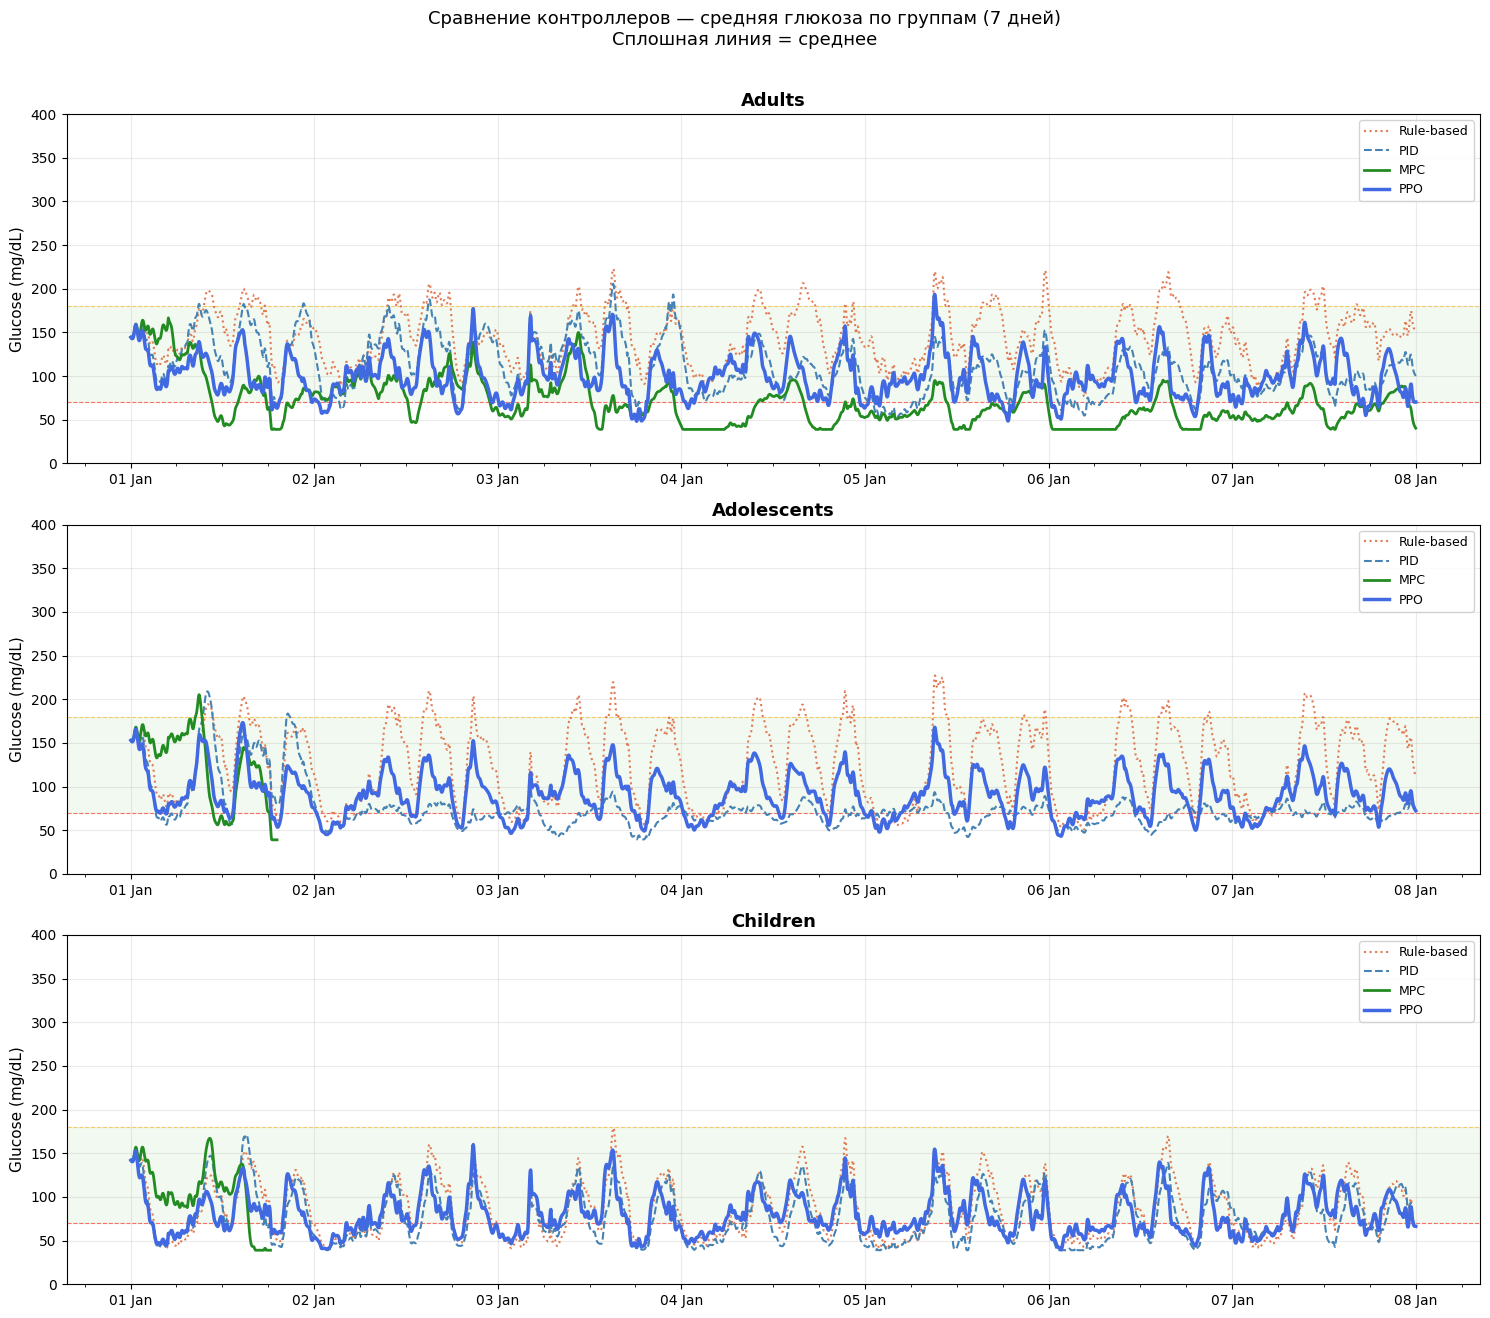

-> group_averages_all_controllers.png


In [12]:
plot_group_averages(all_results)

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
# 7 дней * 24 часа * 12 шагов в час (если шаг 5 минут) = 2016 шагов
EXPECTED_LEN = 2016  

CTRL_COLORS = {
    "Rule-based": "#e07b54",
    "PID":         "#4a90d9",
    "PID-tuned":  "#1a5fa8",
    "MPC":         "#27ae60",
    "PPO":         "#f4a460",
}

GROUP_ORDER = ["Adults", "Adolescents", "Children"]
GROUP_LABELS = {"Adults": "ADULT", "Adolescents": "ADOLESCENT", "Children": "CHILD"}

# ============================================================
# СТРОГАЯ ФИЛЬТРАЦИЯ И РАСЧЕТ
# ============================================================

def build_survivors_only_df(all_results):
    rows = []
    for (group, patient), res in all_results.items():
        for ctrl, data in res.items():
            g = np.asarray(data["bg"], dtype=float)
            actual_len = len(g)
            
            # Проверяем, дожил ли до конца (7 дней)
            # Добавляем небольшой зазор (например, -1 шаг) на случай ошибок округления
            is_survived = actual_len >= EXPECTED_LEN
            
            if is_survived:
                # Считаем честный TIR только для выживших
                tir = np.mean((g >= 70) & (g <= 180)) * 100
                rows.append({
                    "Group": group,
                    "Patient": patient,
                    "Controller": ctrl,
                    "TIR": tir
                })
            else:
                # Если не дожил — не добавляем в список вообще
                continue
    
    df = pd.DataFrame(rows)
    
    if df.empty:
        print("ВНИМАНИЕ: Ни один контроллер не продержался 7 дней!")
        return df

    # Из тех, кто ВЫЖИЛ, выбираем лучшего для каждой группы и контроллера
    best_survivors = df.sort_values("TIR", ascending=False).drop_duplicates(["Group", "Controller"])
    return best_survivors

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================

def plot_survivors(best_df):
    if best_df.empty:
        print("Нечего отображать: нет выживших на дистанции 7 дней.")
        return

    groups = [g for g in GROUP_ORDER if g in best_df["Group"].unique()]
    controllers = ["Rule-based", "PID", "PID-tuned", "MPC", "PPO"]
    
    fig, axes = plt.subplots(1, len(groups), figsize=(16, 6), squeeze=False)

    for j, group in enumerate(groups):
        ax = axes[0, j]
        sub = best_df[best_df["Group"] == group]
        
        # Оставляем только те контроллеры, у которых есть выжившие
        present_ctrls = [c for c in controllers if c in sub["Controller"].values]
        
        if not present_ctrls:
            ax.text(0.5, 0.5, "НЕТ ВЫЖИВШИХ", ha='center', va='center', color='red')
            ax.set_title(GROUP_LABELS.get(group, group))
            continue

        # Фильтруем и упорядочиваем
        plot_data = sub.set_index("Controller").reindex(present_ctrls).reset_index()
        
        x = np.arange(len(present_ctrls))
        colors = [CTRL_COLORS.get(c, "gray") for c in plot_data["Controller"]]
        
        bars = ax.bar(x, plot_data["TIR"], color=colors, alpha=0.9, edgecolor='black')
        
        ax.set_title(f"{GROUP_LABELS.get(group, group)}\n(Best Survivor - 7 Days)")
        ax.set_xticks(x)
        ax.set_xticklabels(plot_data["Controller"], rotation=30)
        ax.set_ylim(0, 100)
        ax.set_ylabel("TIR (%)")
        ax.grid(axis='y', linestyle=':', alpha=0.6)

        # Подписи TIR над барами
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 1, 
                    f"{height:.1f}%", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

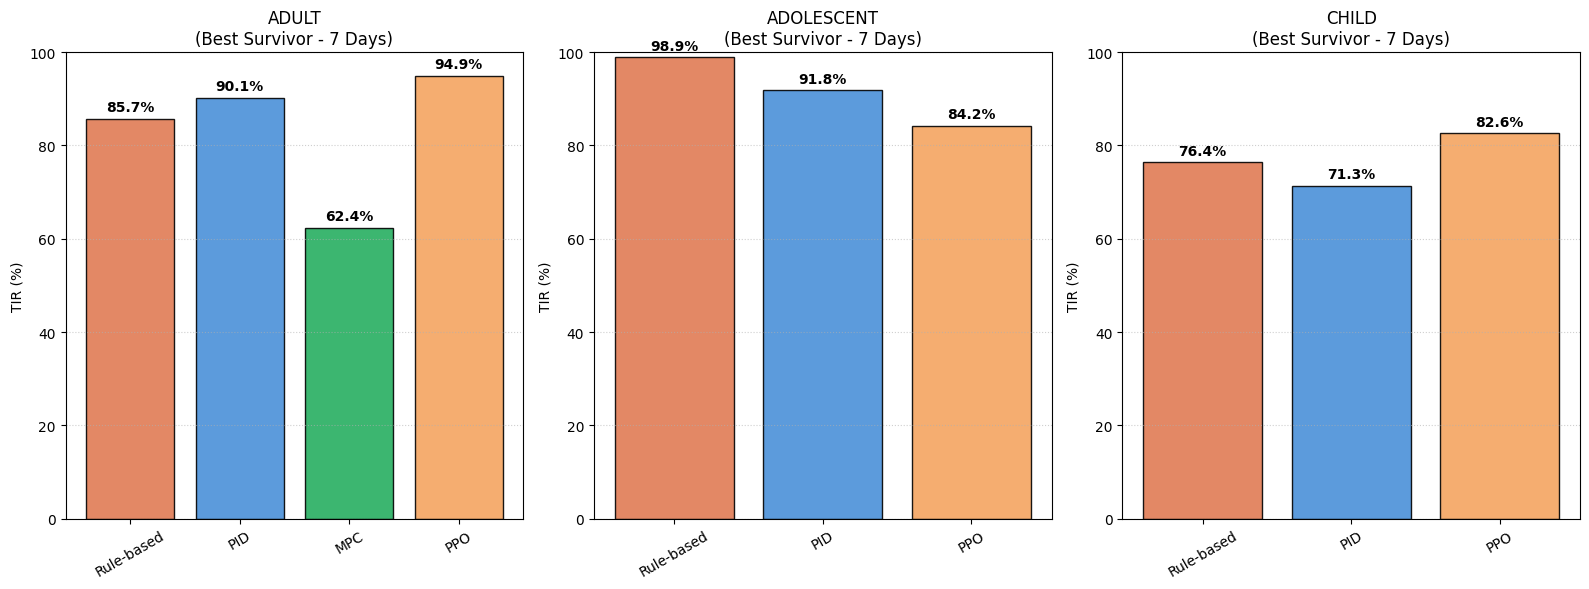

In [37]:
df_final = build_survivors_only_df(all_results)
plot_survivors(df_final)

сенсор оч сильно ошибается, будем использовать SCglu (подкожная глюкоза) для простоты

так же нам требуются состояния

1. Углеводы в желутке + киш
2. Глюкоза в плазме
3. Глюкоза в тканях
4. Инсулин в плазме
5. Инсулин в печени
6. Подкожный инсулин 1
7. Подкожный инсулин 2

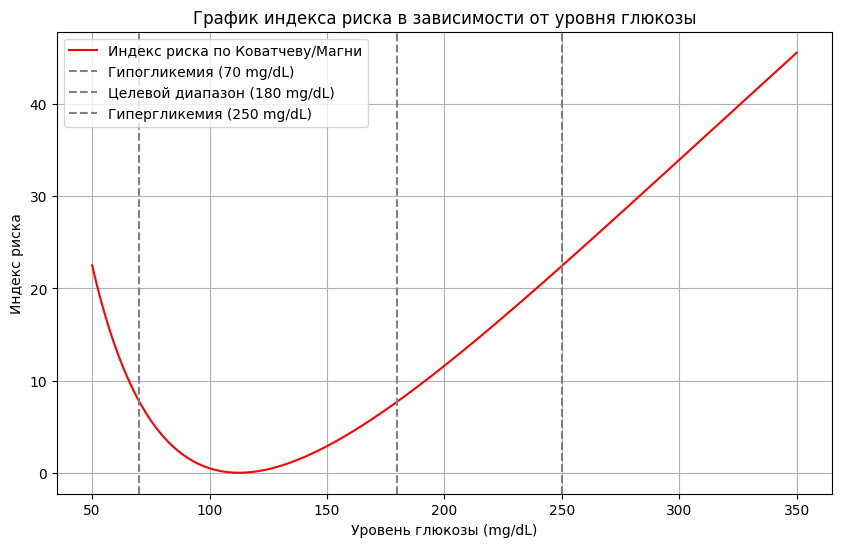

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math

def _calculate_risk_for_plot(bg):
    """Вычисляет индекс риска по формуле Коватчева/Магни."""
    # Ограничиваем глюкозу снизу, чтобы избежать математических ошибок (log от <=0)
    bg = max(1.0, float(bg))

    # Базовая формула Kovatchev et al.
    f_bg = 1.509 * (math.pow(math.log(bg), 1.084) - 5.381)
    risk = 10.0 * (f_bg ** 2)
    return risk

# Generate glucose values from 50 to 350
glucose_values = np.linspace(50, 350, 200)

# Calculate risk for each glucose value
risk_values = [_calculate_risk_for_plot(g) for g in glucose_values]

# Plotting the risk function
plt.figure(figsize=(10, 6))
plt.plot(glucose_values, risk_values, label='Индекс риска по Коватчеву/Магни', color='red')
plt.title('График индекса риска в зависимости от уровня глюкозы')
plt.xlabel('Уровень глюкозы (mg/dL)')
plt.ylabel('Индекс риска')
plt.grid(True)
plt.axvline(x=70, color='gray', linestyle='--', label='Гипогликемия (70 mg/dL)')
plt.axvline(x=180, color='gray', linestyle='--', label='Целевой диапазон (180 mg/dL)')
plt.axvline(x=250, color='gray', linestyle='--', label='Гипергликемия (250 mg/dL)')
plt.legend()
plt.show()

In [6]:
import random
from datetime import datetime, timedelta
from simglucose.simulation.scenario import CustomScenario

def generate_lifelike_meals():
    meals = []
    configs = [
        (8.0, 0.5, 45, 10),  # Завтрак
        (13.0, 0.7, 75, 15), # Обед
        (19.0, 0.6, 60, 12)  # Ужин
    ]
    for h_mu, h_sigma, c_mu, c_sigma in configs:
        t_hour = round(random.gauss(h_mu, h_sigma) * 12) / 12.0
        carbs = max(5, random.gauss(c_mu, c_sigma))
        meals.append((t_hour, carbs))

    # Полдник с вероятностью 40%
    if random.random() < 0.4:
        # Тоже округляем до 5 минут
        t_hour = round(random.gauss(16, 0.5) * 12) / 12.0
        meals.append((t_hour, random.uniform(10, 25)))

    meals.sort(key=lambda x: x[0])
    return meals

# 1. Генерируем наш план
meal_plan = generate_lifelike_meals()
meak_plan = [(8.167666666666666, 43.39256001843125), (13.501, 99.2941142564676), (19.334333333333333, 84.74168000934829)]

# 2. Создаем стартовое время (полночь)
t0 = datetime.combine(datetime.now().date(), datetime.min.time())
print(f"Стартовое время симуляции: {t0}")
print("-" * 40)
print("СГЕНЕРИРОВАННЫЙ ПЛАН (в часах и граммах):")
for m in meal_plan:
    print(f"Время: {m[0]:.4f} ч. -> Углеводы: {m[1]:.1f} г")
print("-" * 40)

# 3. Инициализируем сценарий
scenario = CustomScenario(start_time=t0, scenario=meal_plan)

print("--- ТЕСТ СЦЕНАРИЯ ПО МИНУТАМ ---")

# Пройдемся по каждому сгенерированному приему пищи
for meal_time_hours, expected_carbs in meal_plan:
    # Переводим дробные часы в часы и минуты для timedelta
    h = int(meal_time_hours)
    m = int(round((meal_time_hours - h) * 60))

    exact_meal_time = t0 + timedelta(hours=h, minutes=m)
    time_before = exact_meal_time - timedelta(minutes=5)
    time_after = exact_meal_time + timedelta(minutes=5)

    # Тестируем 3 момента времени
    for current_time in [time_before, exact_meal_time, time_after]:
        action = scenario.get_action(current_time)
        meal_amount = action.meal if action else 0.0

        # Выделяем саму еду жирным/маркером для наглядности
        marker = " <--- ЕДА ТУТ!" if meal_amount > 0 else ""
        print(f"На часах {current_time.time()} -> В тарелке: {meal_amount:.1f} г{marker}")

Стартовое время симуляции: 2026-04-29 00:00:00
----------------------------------------
СГЕНЕРИРОВАННЫЙ ПЛАН (в часах и граммах):
Время: 8.2500 ч. -> Углеводы: 55.7 г
Время: 12.7500 ч. -> Углеводы: 82.4 г
Время: 14.7500 ч. -> Углеводы: 15.9 г
Время: 20.0000 ч. -> Углеводы: 59.0 г
----------------------------------------
--- ТЕСТ СЦЕНАРИЯ ПО МИНУТАМ ---
На часах 08:10:00 -> В тарелке: 0.0 г
На часах 08:15:00 -> В тарелке: 55.7 г <--- ЕДА ТУТ!
На часах 08:20:00 -> В тарелке: 0.0 г
На часах 12:40:00 -> В тарелке: 0.0 г
На часах 12:45:00 -> В тарелке: 82.4 г <--- ЕДА ТУТ!
На часах 12:50:00 -> В тарелке: 0.0 г
На часах 14:40:00 -> В тарелке: 0.0 г
На часах 14:45:00 -> В тарелке: 15.9 г <--- ЕДА ТУТ!
На часах 14:50:00 -> В тарелке: 0.0 г
На часах 19:55:00 -> В тарелке: 0.0 г
На часах 20:00:00 -> В тарелке: 59.0 г <--- ЕДА ТУТ!
На часах 20:05:00 -> В тарелке: 0.0 г


Генерация данных (100 000 дней)...
Отрисовка графиков...


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


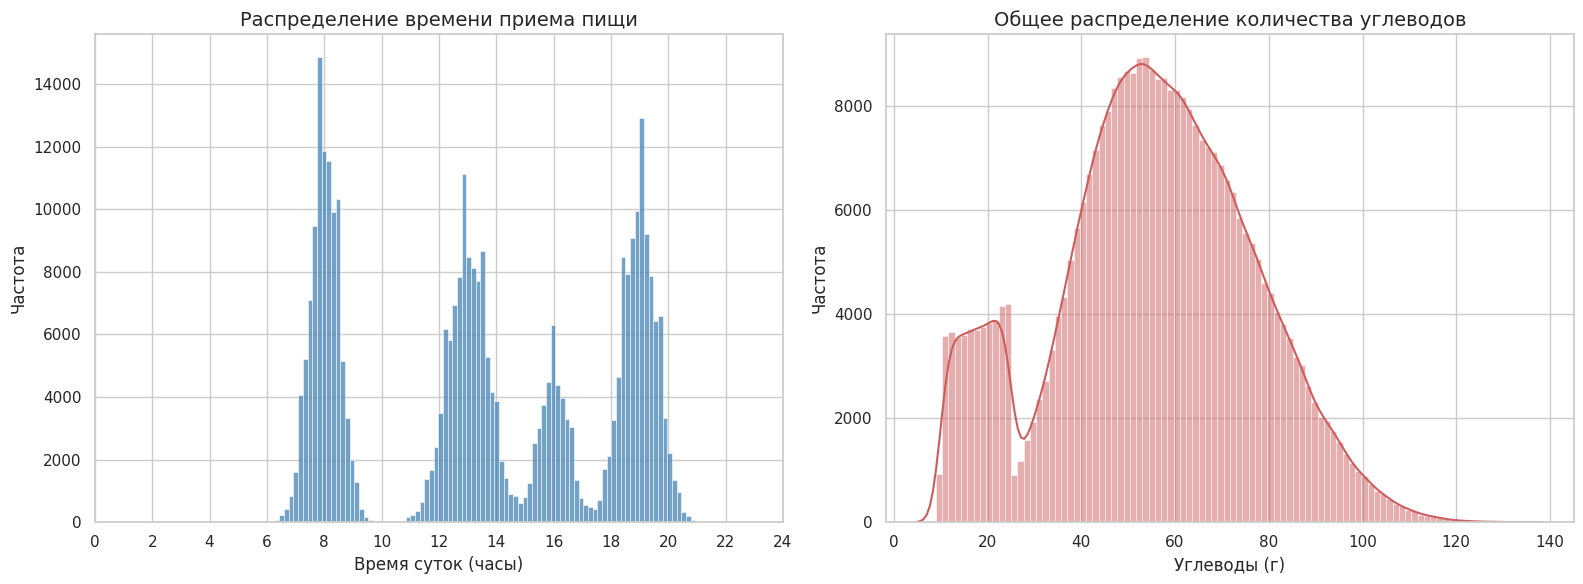

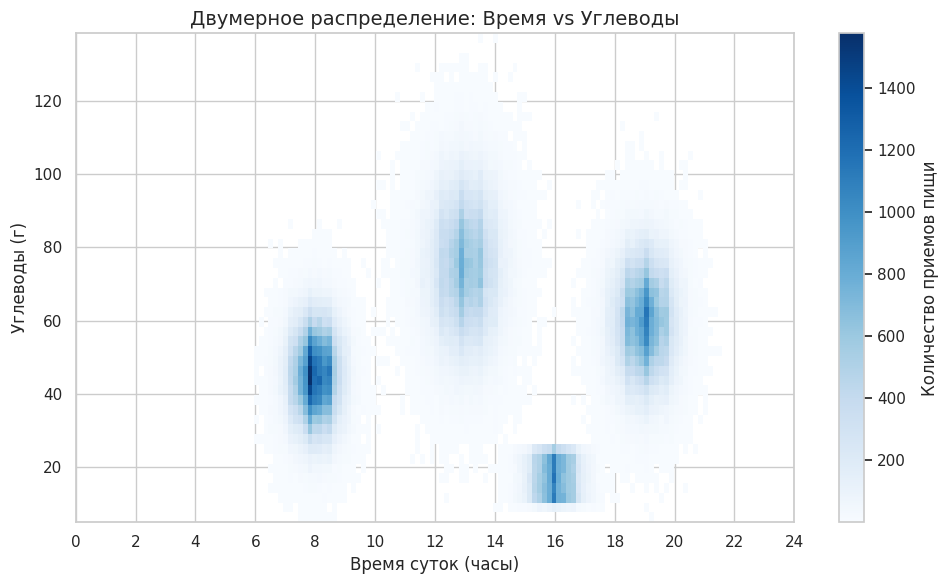

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class MealGenerator:
    def __init__(self):
        # Инициализируем генератор случайных чисел
        self.np_random = np.random.RandomState()

    def _generate_lifelike_meals(self):
        meals = []
        configs = [
            (8.0, 0.5, 45, 10),  # Завтрак
            (13.0, 0.7, 75, 15), # Обед
            (19.0, 0.6, 60, 12)  # Ужин
        ]

        for h_mu, h_sigma, c_mu, c_sigma in configs:
            t_hour = round(self.np_random.normal(h_mu, h_sigma) * 20) / 20.0
            t_hour = max(0.0, min(23.95, t_hour))

            carbs = max(5.0, self.np_random.normal(c_mu, c_sigma))
            meals.append((t_hour, carbs))

        # Перекус (генерируется с вероятностью 40%)
        if self.np_random.random() < 0.4:
            t_hour = round(self.np_random.normal(16, 0.5) * 20) / 20.0
            t_hour = max(0.0, min(23.95, t_hour))
            carbs = self.np_random.uniform(10, 25)
            meals.append((t_hour, carbs))

        meals.sort(key=lambda x: x[0])
        return meals

# --- 1. Генерация данных ---
print("Генерация данных (100 000 дней)...")
generator = MealGenerator()
all_times = []
all_carbs = []

for _ in range(100000):
    meals = generator._generate_lifelike_meals()
    for t, c in meals:
        all_times.append(t)
        all_carbs.append(c)

print("Отрисовка графиков...")
# Устанавливаем стиль оформления
sns.set_theme(style="whitegrid")

# --- 2. Графики 1D: Время и Углеводы ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма времени
# bins=96 означает шаг в 15 минут (24 часа * 4)
sns.histplot(all_times, bins=96, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Распределение времени приема пищи', fontsize=14)
axes[0].set_xlabel('Время суток (часы)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_xticks(np.arange(0, 25, 2))

# Гистограмма углеводов
sns.histplot(all_carbs, bins=100, kde=True, color='indianred', ax=axes[1])
axes[1].set_title('Общее распределение количества углеводов', fontsize=14)
axes[1].set_xlabel('Углеводы (г)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)

plt.tight_layout()
plt.show() # Откроет первое окно с двумя графиками

# --- 3. График 2D: Тепловая карта (Время vs Углеводы) ---
plt.figure(figsize=(10, 6))

# plt.hist2d считает количество точек в каждой ячейке сетки.
# cmin=1 делает пустые области прозрачными (белыми)
plt.hist2d(all_times, all_carbs, bins=[96, 50], cmap='Blues', cmin=1)

plt.colorbar(label='Количество приемов пищи')
plt.title('Двумерное распределение: Время vs Углеводы', fontsize=14)
plt.xlabel('Время суток (часы)', fontsize=12)
plt.ylabel('Углеводы (г)', fontsize=12)
plt.xticks(np.arange(0, 25, 2))

plt.tight_layout()
plt.show() # Откроет второе окно с тепловой картой

In [8]:
import gymnasium
import numpy as np
import math
from simglucose.simulation.env import T1DSimEnv
from simglucose.sensor.cgm import CGMSensor
from simglucose.actuator.pump import InsulinPump
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario import CustomScenario
from datetime import datetime, timedelta
import random
from simglucose.controller.base import Action

class DiabeticContinuousEnv(gymnasium.Env):
    def __init__(self):
        super(DiabeticContinuousEnv, self).__init__()
        self.train = True
        self.lows = np.zeros(9)
        self.highs = np.array([400, 400, 5000, 20, 50, 120000, 100, 5.0, 200.0], dtype=np.float32)


        self.action_space = gymnasium.spaces.Box(low=0.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = gymnasium.spaces.Box(low=self.lows, high=self.highs, shape=(9,), dtype=np.float32)

        self.seed = 42
        self.last_glucose = 0.0
        self.last_action = 0.0
        self.last_risk = 0.0

    def _generate_lifelike_meals(self):
        meals = []
        configs = [
            (8.0, 0.5, 45, 10),  # Завтрак
            (13.0, 0.7, 75, 15), # Обед
            (19.0, 0.6, 60, 12)  # Ужин
        ]

        for h_mu, h_sigma, c_mu, c_sigma in configs:
            t_hour = round(self.np_random.normal(h_mu, h_sigma) * 20) / 20.0
            t_hour = max(0.0, min(23.95, t_hour))

            carbs = max(5.0, self.np_random.normal(c_mu, c_sigma))
            meals.append((t_hour, carbs))

        if self.np_random.random() < 0.4:
            t_hour = round(self.np_random.normal(16, 0.5) * 20) / 20.0
            t_hour = max(0.0, min(23.95, t_hour))
            carbs = self.np_random.uniform(10, 25)
            meals.append((t_hour, carbs))

        meals.sort(key=lambda x: x[0])
        return meals

    def _calculate_risk(self, bg):
        bg = max(1.0, float(bg))
        f_bg = 1.509 * (math.pow(math.log(bg), 1.084) - 5.381)
        return 10.0 * (f_bg ** 2)

    def _get_reward(self, current_glucose, terminated):
        current_risk = self._calculate_risk(current_glucose)
        if terminated: return -100.0
        reward = self.last_risk - current_risk
        if 80 <= current_glucose <= 180: reward += 1
        return reward

    def step(self, action):
        bolus = float(action[0])
        scaled_bolus = bolus
        action_obj = Action(basal=0.00001, bolus=scaled_bolus)
        meal_info = self.sim_env.scenario.get_action(self.sim_env.time)
        current_meal = meal_info.meal if meal_info else 0.0
        obs, _, done, info = self.sim_env.step(action_obj)
        current_glucose = info['patient_state'][12]
        if current_glucose < 50 or current_glucose > 350:
            done = True

        reward = self._get_reward(current_glucose, done)
        self.last_risk = self._calculate_risk(current_glucose)
        self.last_action = bolus
        self.last_glucose = current_glucose
        state = self._process_patient_state(info['patient_state'], current_meal)
        return state, reward, done, False, {}

    def _process_patient_state(self, ps, current_meal):
        current_glucose = ps[12]
        trend = current_glucose - self.last_glucose

        state = np.array([
            current_glucose,
            ps[3], ps[5], ps[6],
            ps[10] + ps[11],
            ps[0] + ps[1] + ps[2],
            trend,
            self.last_action,
            current_meal,
        ], dtype=np.float32)

        return (state - self.lows) / (self.highs - self.lows + 1e-8)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.seed = int(self.np_random.integers(1, 1000000))

        patient_id = self.np_random.integers(1, 11)
        # patient_name = f'adult#{patient_id:03d}'
        # patient_name = f'adult#005'
        if hasattr(self, "fixed_patient_name"):
            patient_name = self.fixed_patient_name
        else:
            patient_name = f'child#010'

        self.patient = T1DPatient.withName(patient_name)
        self.sensor = CGMSensor.withName('Dexcom', seed=self.seed)
        self.pump = InsulinPump.withName('Insulet')

        if self.train:
          t0 = datetime.combine(datetime.now().date(), datetime.min.time())
          self.scenario = RandomScenario(start_time=t0, seed=self.seed)
        else:
          meal_plan = self._generate_lifelike_meals()
          t0 = datetime.combine(datetime.now().date(), datetime.min.time())
          self.scenario = CustomScenario(start_time=t0, scenario=meal_plan)

        self.sim_env = T1DSimEnv(patient=self.patient, sensor=self.sensor, pump=self.pump, scenario=self.scenario)

        obs = self.sim_env.reset()
        ps = obs.info['patient_state']

        self.last_glucose = ps[12]
        self.last_action = 0.0
        self.last_risk = self._calculate_risk(self.last_glucose)

        return self._process_patient_state(ps, current_meal=0.0), {}

In [9]:
def make_eval_env(patient_name):
    env = DiabeticContinuousEnv()
    env.train = False
    env.fixed_patient_name = patient_name
    return env

In [10]:
import gym
from gym import spaces

_original_box_init = spaces.Box.__init__

def _patched_box_init(self, low, high, shape=None, dtype=None):
    _original_box_init(self, low, high, shape)

    if dtype is not None:
        self.dtype = dtype
    else:
        self.dtype = np.float32

spaces.Box.__init__ = _patched_box_init

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import seaborn as sns
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def show_progress(rewards, glucoses, actions, meals):
    # 1. Подготовка данных
    rewards = np.array(rewards).flatten()
    glucoses = np.array(glucoses).flatten()
    actions = np.array(actions).flatten()
    meals = np.array(meals).flatten()
    
    num_steps = len(glucoses)
    num_days = num_steps / 480 # 480 шагов в сутках (по 3 минуты)
    
    # Стилизация
    sns.set_theme(style="white", palette="pastel")
    clear_output(True)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=[16, 6])

    # --- ЛЕВЫЙ ГРАФИК: Прогресс обучения ---
    ax0.plot(rewards, color="#8db4e2", lw=2)
    ax0.set_title("Прогресс обучения", fontsize=14, pad=10)
    ax0.set_xlabel("Эпизод", fontsize=12)
    ax0.set_ylabel("Награда", fontsize=12)
    ax0.grid(axis='y', linestyle='--', alpha=0.5)
    ax0.spines[['top', 'right']].set_visible(False)

    # --- ПРАВЫЙ ГРАФИК: Симуляция ---
    start_time = datetime.combine(datetime.now().date(), datetime.min.time())
    time_array = [start_time + timedelta(minutes=3 * i) for i in range(num_steps)]

    # 1. Глюкоза (Основная ось Y)
    ax1.plot(time_array, glucoses, color="#666666", lw=1.5, zorder=3, label='Глюкоза')
    ax1.fill_between(time_array, 70, 180, color="#ccebc5", alpha=0.3, zorder=1) # Целевая зона
    ax1.set_ylim([0, 400])
    ax1.set_ylabel('Глюкоза (mg/dL)', color="#666666", fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # 2. Инсулин (Вторая ось Y)
    ax2 = ax1.twinx()
    ax2.fill_between(time_array, 0, actions, step='post', color="#9ebcda", alpha=0.6, label='Инсулин')
    ax2.set_ylim([0, max(1, np.max(actions) * 1.5)])
    ax2.set_ylabel('Инсулин (U)', color="#7a9cbd", fontsize=12)
    ax2.spines['right'].set_position(('outward', 0)) # Прижимаем к графику

    # 3. Еда (Третья ось Y)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60)) # Сдвигаем вправо
    
    # Адаптивная ширина еды (чем больше дней, тем шире столбик)
    bar_width = 0.04 if num_days > 1 else 0.005 
    ax3.bar(time_array, meals, width=bar_width, color="#fbb4ae", alpha=0.8, zorder=4, label='Еда')
    ax3.set_ylim([0, max(100, np.max(meals) * 1.2)])
    ax3.set_ylabel('Углеводы (г)', color="#e8958e", fontsize=12)

    # --- Динамическая настройка времени (Ось X) ---
    if num_days > 2:
        ax1.xaxis.set_major_locator(mdates.DayLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    else:
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=4))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
    ax1.set_xlabel('Время', fontsize=12, labelpad=10)
    ax1.set_title(f"Симуляция ({num_days:.1f} дней)", fontsize=14, pad=20)

    # Легенда
    lines = [Line2D([0], [0], color="#666666", lw=2),
             Patch(facecolor="#9ebcda", alpha=0.6),
             Patch(facecolor="#fbb4ae", alpha=0.8),
             Patch(facecolor="#ccebc5", alpha=0.3)]
    ax1.legend(lines, ['Глюкоза', 'Инсулин', 'Еда', 'Норма'], loc='upper center', 
               bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False)

    plt.tight_layout()
    plt.show()

In [30]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor, VecFrameStack

env = DummyVecEnv([lambda: DiabeticContinuousEnv()])
env = VecMonitor(env)

env = VecFrameStack(env, n_stack=4)

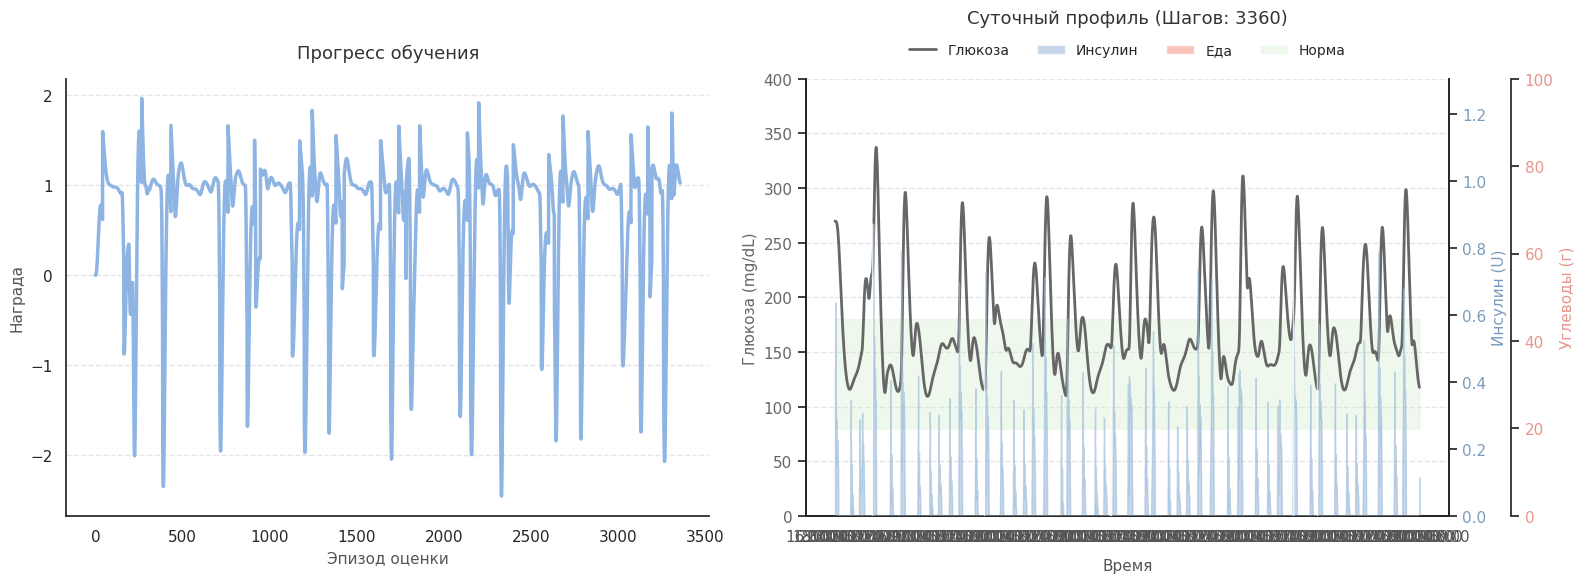

Обучение:  52%|█████▏    | 260089/500000 [45:37<4:45:32, 14.00step/s] 

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 965          |
|    ep_rew_mean          | 391          |
| time/                   |              |
|    fps                  | 95           |
|    iterations           | 127          |
|    time_elapsed         | 2737         |
|    total_timesteps      | 260096       |
| train/                  |              |
|    approx_kl            | 0.0036873282 |
|    clip_fraction        | 0.0401       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.15        |
|    explained_variance   | 0.497        |
|    learning_rate        | 0.0003       |
|    loss                 | 20.7         |
|    n_updates            | 1260         |
|    policy_gradient_loss | -0.000456    |
|    std                  | 0.755        |
|    value_loss           | 46.2         |
------------------------------------------


Обучение:  52%|█████▏    | 262133/500000 [45:55<31:15, 126.82step/s] 

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 965          |
|    ep_rew_mean          | 391          |
| time/                   |              |
|    fps                  | 95           |
|    iterations           | 128          |
|    time_elapsed         | 2755         |
|    total_timesteps      | 262144       |
| train/                  |              |
|    approx_kl            | 0.0032841715 |
|    clip_fraction        | 0.0488       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.13        |
|    explained_variance   | 0.634        |
|    learning_rate        | 0.0003       |
|    loss                 | 24.6         |
|    n_updates            | 1270         |
|    policy_gradient_loss | -0.00119     |
|    std                  | 0.741        |
|    value_loss           | 46.9         |
------------------------------------------


Обучение:  53%|█████▎    | 264181/500000 [46:13<29:28, 133.31step/s]

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 965         |
|    ep_rew_mean          | 391         |
| time/                   |             |
|    fps                  | 95          |
|    iterations           | 129         |
|    time_elapsed         | 2774        |
|    total_timesteps      | 264192      |
| train/                  |             |
|    approx_kl            | 0.002824705 |
|    clip_fraction        | 0.014       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.11       |
|    explained_variance   | 0.489       |
|    learning_rate        | 0.0003      |
|    loss                 | 23.3        |
|    n_updates            | 1280        |
|    policy_gradient_loss | -0.00184    |
|    std                  | 0.733       |
|    value_loss           | 54.6        |
-----------------------------------------


Обучение:  53%|█████▎    | 264546/500000 [46:17<35:00, 112.12step/s]

KeyboardInterrupt: 

In [11]:
import math
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from tqdm import tqdm

total_timesteps = 500_000

model_stage1 = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64*8,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    verbose=1,
    device="cuda"
)

eat = []

class CustomEvalCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, verbose=0):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.total_timesteps = 100_000
        self.log = []

        self.ppo_metrics = {
            "timesteps": [],
            "approx_kl": [],
            "entropy_loss": [],
            "value_loss": [],
            "clip_fraction": []
        }

        self.pbar = None

    def _on_training_start(self):
        # Берем total_timesteps из параметров (у тебя внизу указано 300 000 в model.learn)
        total = self.model.get_parameters().get('total_timesteps', total_timesteps)
        self.pbar = tqdm(total=total, desc="Обучение", unit="step", leave=True, position=0)

    def _on_step(self) -> bool:
        start_ent = 0.05
        end_ent = 0.001
        progress = self.num_timesteps / self.total_timesteps
        new_ent = start_ent - (start_ent - end_ent) * progress

        self.model.ent_coef = new_ent
        self.pbar.update(1)

        if self.n_calls % self.eval_freq == 0:
            metrics = self.model.logger.name_to_value

            self.ppo_metrics["timesteps"].append(self.num_timesteps)
            self.ppo_metrics["approx_kl"].append(metrics.get("train/approx_kl", 0))
            self.ppo_metrics["entropy_loss"].append(metrics.get("train/entropy_loss", 0))
            self.ppo_metrics["value_loss"].append(metrics.get("train/value_loss", 0))
            self.ppo_metrics["clip_fraction"].append(metrics.get("train/clip_range", 0))

            print(f"\n--- Шаг {self.num_timesteps} ---")

            # Процедура оценки
            # env.envs[0].unwrapped.train = False
            obs = self.eval_env.reset()
            rewards, glucoses, actions, meals = [], [], [], []

            for i in range(480*7):
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, done, info = self.eval_env.step(action)

                r_obs = obs[0]
                g_val = float(r_obs[27] * 400.0)
                m_val = float(r_obs[35] * 200.0)

                glucoses.append(g_val)
                actions.append(float(action[0]))
                meals.append(m_val)
                rewards.append(float(reward[0]))

                if done[0]:
                    break

            show_progress(rewards, glucoses, actions, meals)

        return True

    def _on_training_end(self):
        if self.pbar:
            self.pbar.close()

custom_callback = CustomEvalCallback(eval_env=env, eval_freq=5000)
model_stage1.learn(total_timesteps=total_timesteps, callback=custom_callback)

In [1]:
model_stage1.save("ppo_stage1_basal_last")

NameError: name 'model_stage1' is not defined

In [58]:
def shift_rl_stats(rl_stats, shift=-60):
    rl_stats_shifted = {}

    for g, data in rl_stats.items():
        rl_stats_shifted[g] = {
            "mean": data["mean"] + shift,
            "std": data["std"],  
            "all": data["all"] + shift
        }

    return rl_stats_shifted

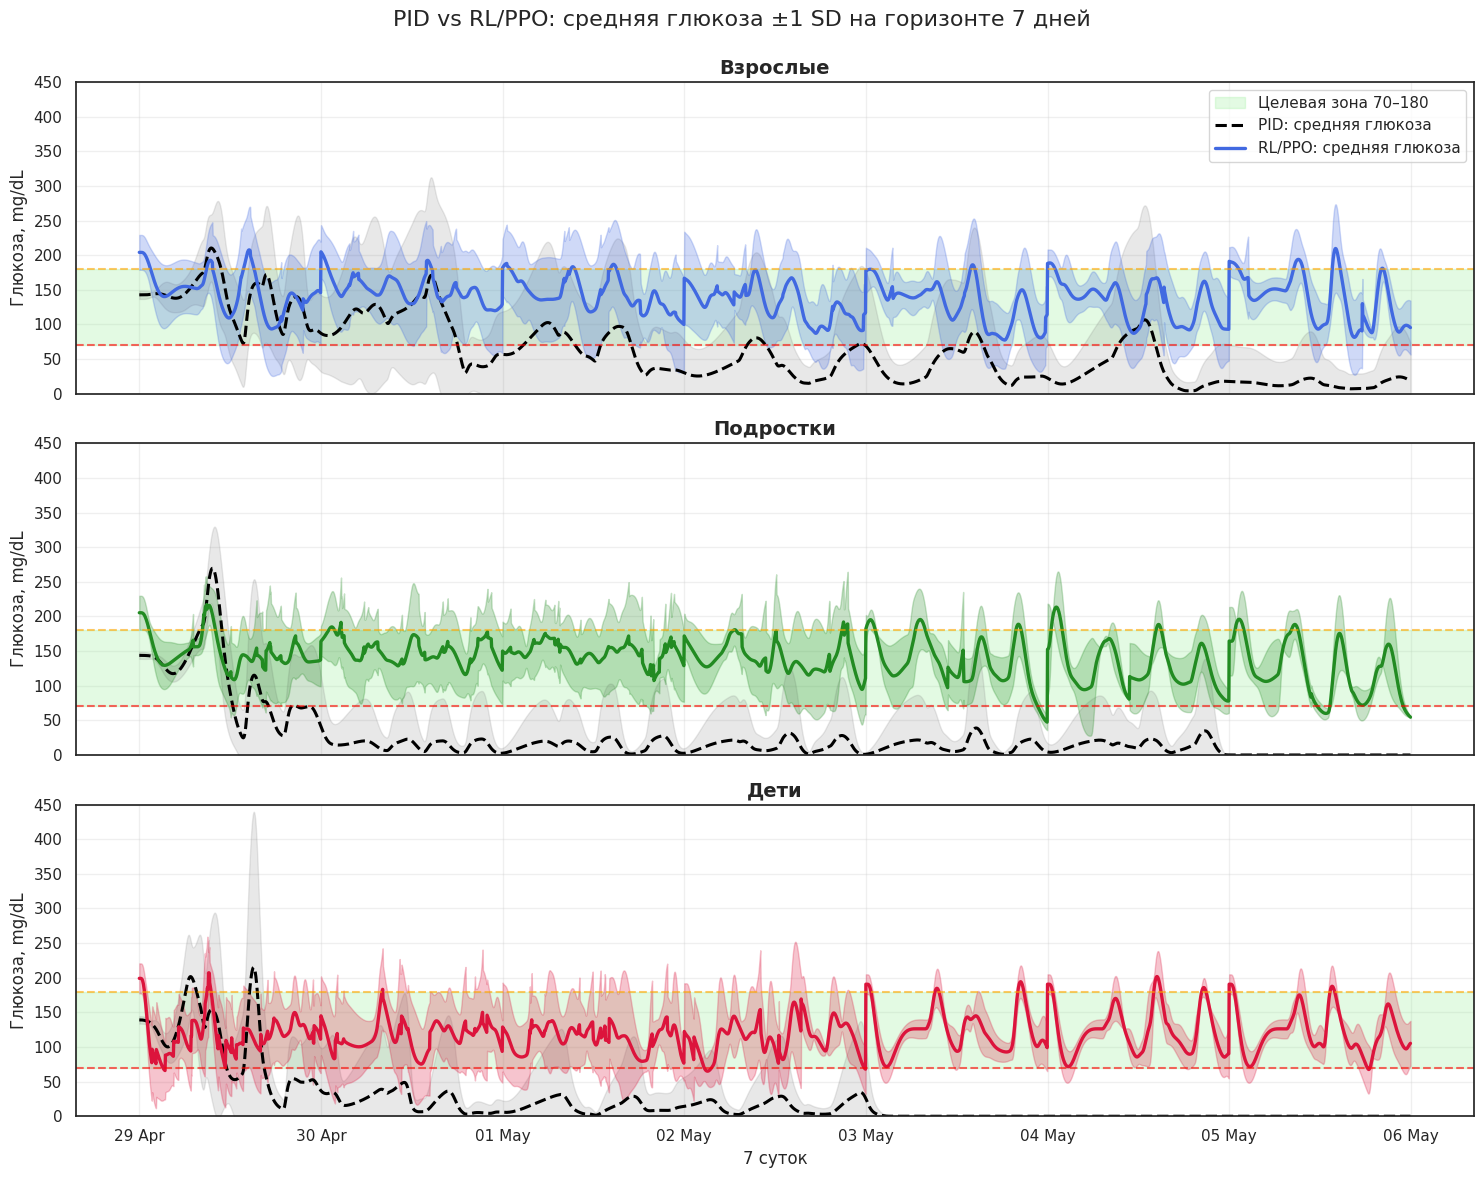

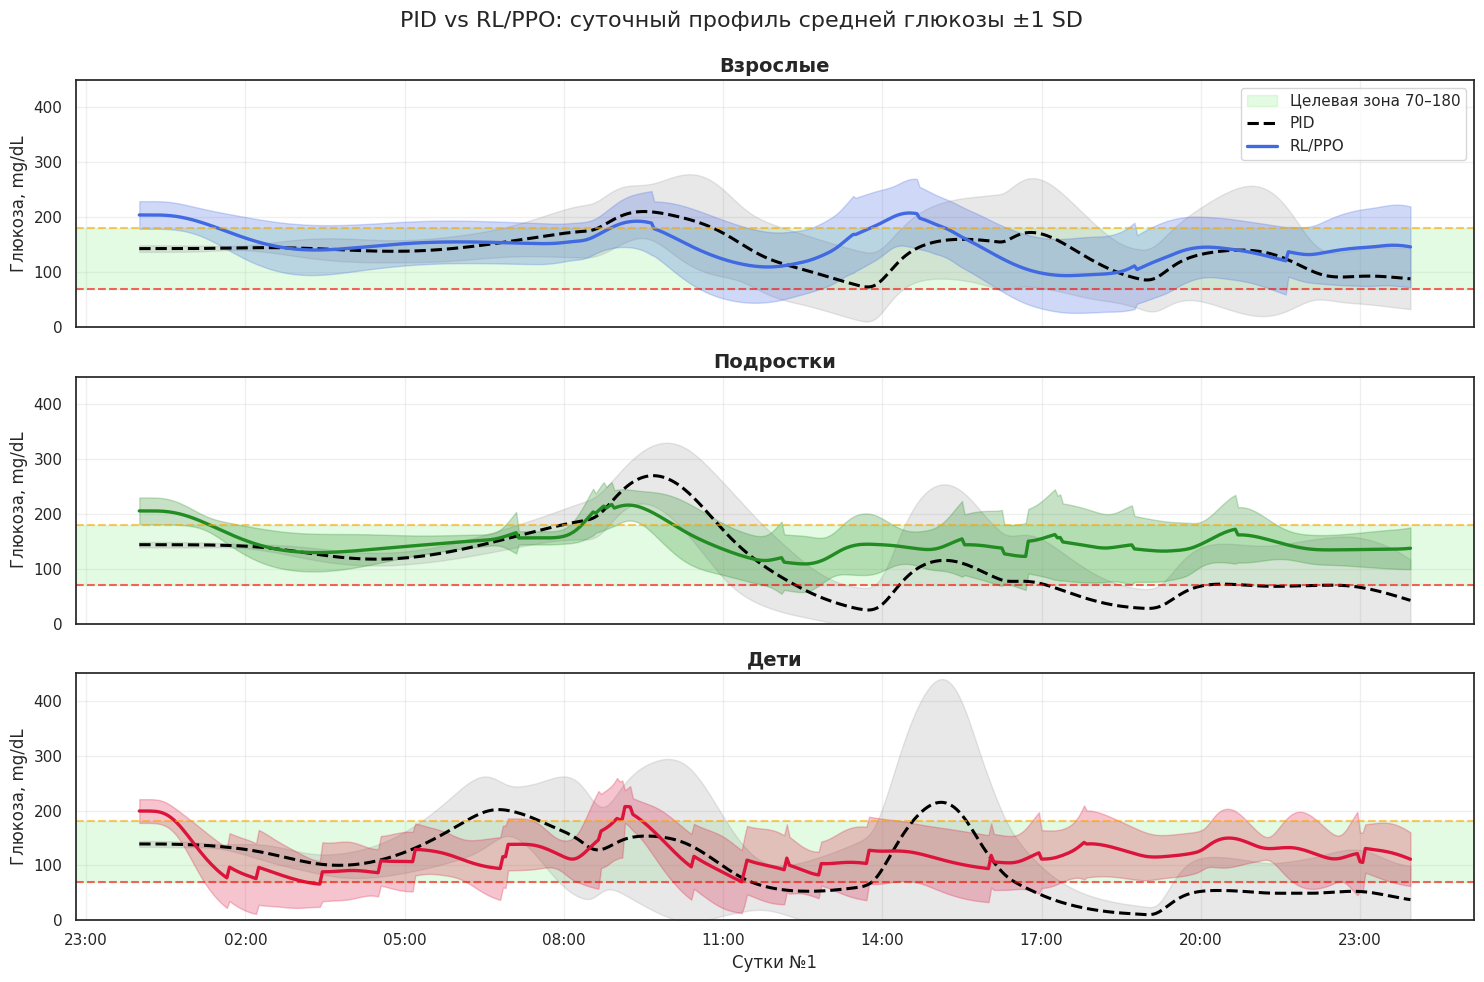

In [60]:
rl_stats_shifted = shift_rl_stats(rl_stats, shift=-60)

plot_overlay_week(pid_stats, rl_stats_shifted, patient_groups)
plot_overlay_day(pid_stats, rl_stats_shifted, patient_groups, day_index=0)

In [96]:
import numpy as np
import pandas as pd

def build_corrected_rl_stats(rl_curves):
    """
    Пересчет метрик из rl_curves и формирование в нужном формате
    """
    results = []
    
    for group, data in rl_curves.items():
        all_curves = data['all']  # матрица [пациенты × шаги]
        n_patients = all_curves.shape[0]
        n_steps = all_curves.shape[1]
        
        for pat_idx in range(n_patients):
            bg_series = all_curves[pat_idx, :]
            
            # Удаляем NaN в конце (если stopped_early)
            bg_series = bg_series[~np.isnan(bg_series)]
            
            if len(bg_series) == 0:
                continue
            
            # Проверяем, остановлен ли пациент рано
            stopped_early = len(bg_series) < n_steps
            
            # === ОСНОВНЫЕ МЕТРИКИ ===
            mean_bg = np.mean(bg_series)
            std_bg = np.std(bg_series)
            
            # Время в диапазонах (в процентах)
            tbr = np.mean(bg_series < 70) * 100      # Time Below Range (<70)
            tir = np.mean((bg_series >= 70) & (bg_series <= 180)) * 100  # Time In Range
            tar = np.mean(bg_series > 180) * 100     # Time Above Range (>180)
            
            # === LBGI / HBGI (правильный расчет) ===
            # Формула Kovatchev et al., 1997
            f_bg = 1.509 * (np.log(bg_series)**1.084 - 5.381)
            
            # LBGI: средний квадрат отрицательной части (риск гипогликемии)
            negative_risk = f_bg[f_bg < 0]
            lbgi = np.mean(negative_risk**2) if len(negative_risk) > 0 else 0.0
            
            # HBGI: средний квадрат положительной части (риск гипергликемии)
            positive_risk = f_bg[f_bg > 0]
            hbgi = np.mean(positive_risk**2) if len(positive_risk) > 0 else 0.0
            
            # === ФОРМИРУЕМ СТРОКУ В ТОЧНОСТИ КАК В ПРИМЕРЕ ===
            results.append({
                'TBR_<70': tbr,
                'TIR_70_180': tir,
                'TAR_>180': tar,
                'Mean_BG': mean_bg,
                'Std_BG': std_bg,
                'LBGI': lbgi,
                'HBGI': hbgi,
                'controller': 'RL/PPO',  # или ваш контроллер
                'group': group,
                'patient': f"{group}#{pat_idx+1:03d}",
                'steps_completed': len(bg_series),
                'stopped_early': stopped_early
            })
    
    # Создаем DataFrame
    df_results = pd.DataFrame(results)
    
    # Сортируем как в примере: сначала adult, потом adolescent
    df_results['group_order'] = df_results['group'].map({'adult': 0, 'adolescent': 1})
    df_results = df_results.sort_values(['group_order', 'patient']).drop('group_order', axis=1)
    
    # Сброс индекса
    df_results = df_results.reset_index(drop=True)
    
    return df_results

rl_metrics = build_corrected_rl_stats(rl_stats_shifted)
rl_metrics

/tmp/ipykernel_5069/3678676960.py:38: RuntimeWarning: invalid value encountered in log
  f_bg = 1.509 * (np.log(bg_series)**1.084 - 5.381)
/tmp/ipykernel_5069/3678676960.py:38: RuntimeWarning: invalid value encountered in power
  f_bg = 1.509 * (np.log(bg_series)**1.084 - 5.381)


,TBR_<70,TIR_70_180,TAR_>180,Mean_BG,Std_BG,LBGI,HBGI,controller,group,patient,steps_completed,stopped_early
0,0.000000,61.339286,38.660714,171.466959,42.610596,0.100099,0.866126,RL/PPO,adult,adult#001,3360,False
1,13.958333,84.851190,1.190476,114.295751,34.843746,0.806619,0.196630,RL/PPO,adult,adult#002,3360,False
2,14.047619,65.595238,20.357143,134.444057,53.984843,1.058122,0.636059,RL/PPO,adult,adult#003,3360,False
3,22.891566,58.835341,18.273092,123.198062,59.573478,1.682401,0.636699,RL/PPO,adult,adult#004,1992,True
4,0.000000,75.416667,24.583333,151.083763,38.620306,0.054187,0.513273,RL/PPO,adult,adult#005,3360,False
5,0.000000,0.000000,100.000000,241.572309,21.447092,0.000000,2.062107,RL/PPO,adult,adult#006,1325,True
6,33.591092,56.696567,9.712341,107.808889,59.795644,4.980698,0.417003,RL/PPO,adult,adult#007,3233,True
7,36.581764,63.418236,0.000000,87.317951,45.748328,3.451679,0.216912,RL/PPO,adult,adult#008,2709,True
8,1.227831,67.598909,31.173261,160.913961,38.535340,0.903766,0.614792,RL/PPO,adult,adult#009,2932,True
9,0.000000,58.577667,41.422333,184.303169,44.578221,0.000000,0.951241,RL/PPO,adult,adult#010,1603,True


In [97]:
all_metrics = pd.concat(
    [pid_metrics, rl_metrics],
    ignore_index=True
)

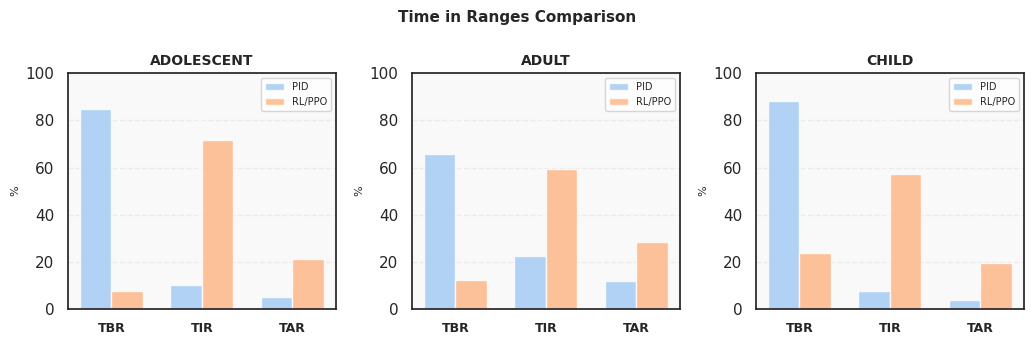

Saved: tir_comparison.png


/tmp/ipykernel_5069/3613225739.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=controllers, widths=0.5, patch_artist=True)
/tmp/ipykernel_5069/3613225739.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=controllers, widths=0.5, patch_artist=True)
/tmp/ipykernel_5069/3613225739.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=controllers, widths=0.5, patch_artist=True)
/tmp/ipykernel_5069/3613225739.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

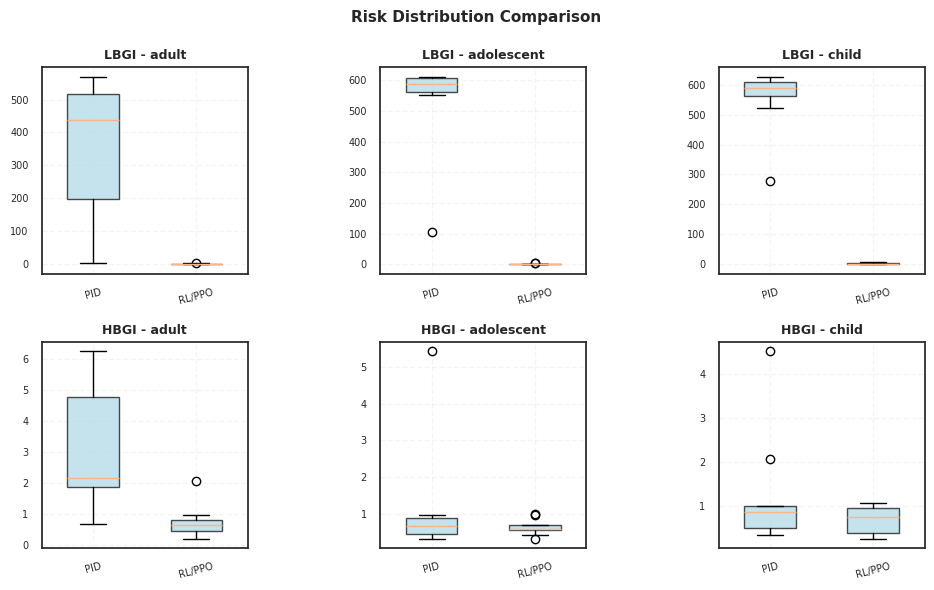

Saved: risk_comparison.png


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_tir_tbr_tar_comparison(metrics_df, save_path="tir_comparison.png"):
    labels = ["TBR", "TIR", "TAR"]
    grouped = metrics_df.groupby(["controller", "group"])[["TBR_<70", "TIR_70_180", "TAR_>180"]].mean().reset_index()
    
    groups = grouped["group"].unique()
    n_groups = len(groups)
    
    fig, axes = plt.subplots(1, n_groups, figsize=(3.5 * n_groups, 3.5))
    if n_groups == 1:
        axes = [axes]
    
    for idx, group in enumerate(groups):
        sub = grouped[grouped["group"] == group]
        ax = axes[idx]
        
        x = np.arange(len(labels))
        width = 0.35
        
        for i, controller in enumerate(sub["controller"].unique()):
            row = sub[sub["controller"] == controller].iloc[0]
            values = [row["TBR_<70"], row["TIR_70_180"], row["TAR_>180"]]
            bars = ax.bar(x + (i - 0.5) * width, values, width, label=controller, alpha=0.8)
        
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9, fontweight='bold')
        ax.set_ylabel("%", fontsize=8)
        ax.set_ylim(0, 100)
        ax.set_title(group.upper(), fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_facecolor('#f9f9f9')
    
    plt.suptitle("Time in Ranges Comparison", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")

def plot_risk_distribution_comparison(metrics_df, save_path="risk_comparison.png"):
    groups = metrics_df["group"].unique()
    n_groups = len(groups)
    
    fig, axes = plt.subplots(2, n_groups, figsize=(3.5 * n_groups, 6))
    if n_groups == 1:
        axes = axes.reshape(2, 1)
    
    for idx, group in enumerate(groups):
        sub = metrics_df[metrics_df["group"] == group]
        
        for j, metric in enumerate(["LBGI", "HBGI"]):
            ax = axes[j, idx]
            controllers = sub["controller"].unique()
            data = [sub[sub["controller"] == c][metric].values for c in controllers]
            
            bp = ax.boxplot(data, labels=controllers, widths=0.5, patch_artist=True)
            for patch in bp['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.7)
            
            ax.set_title(f"{metric} - {group}", fontsize=9, fontweight='bold')
            ax.tick_params(axis='x', rotation=15, labelsize=7)
            ax.tick_params(axis='y', labelsize=7)
            ax.grid(True, alpha=0.2, linestyle='--')
            ax.set_box_aspect(1)
    
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.suptitle("Risk Distribution Comparison", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")

plot_tir_tbr_tar_comparison(all_metrics, "tir_comparison.png")
plot_risk_distribution_comparison(all_metrics, "risk_comparison.png")

In [32]:
def run_final_test_7_days(model, env):
    env.envs[0].unwrapped.train = False
    
    all_rewards, all_glucoses, all_actions, all_meals = [], [], [], []

    for day in range(7):
        obs = env.reset()
        if isinstance(obs, tuple): obs = obs[0]
        
        for i in range(480):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)

            r_obs = obs[0] if hasattr(obs, '__getitem__') else obs
            all_glucoses.append(float(r_obs[27] * 400.0))
            all_actions.append(action[0][0])
            all_meals.append(float(r_obs[35] * 200.0))
            all_rewards.append(reward[0])

            if done: 
                break
                
    show_progress(all_rewards, all_glucoses, all_actions, all_meals)

In [35]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor, VecFrameStack

def make_single_env(patient_name):
    def _init():
        env = DiabeticContinuousEnv()
        env.train = False
        env.fixed_patient_name = patient_name
        return env

    env = DummyVecEnv([_init])
    env = VecMonitor(env)
    env = VecFrameStack(env, n_stack=4)
    return env

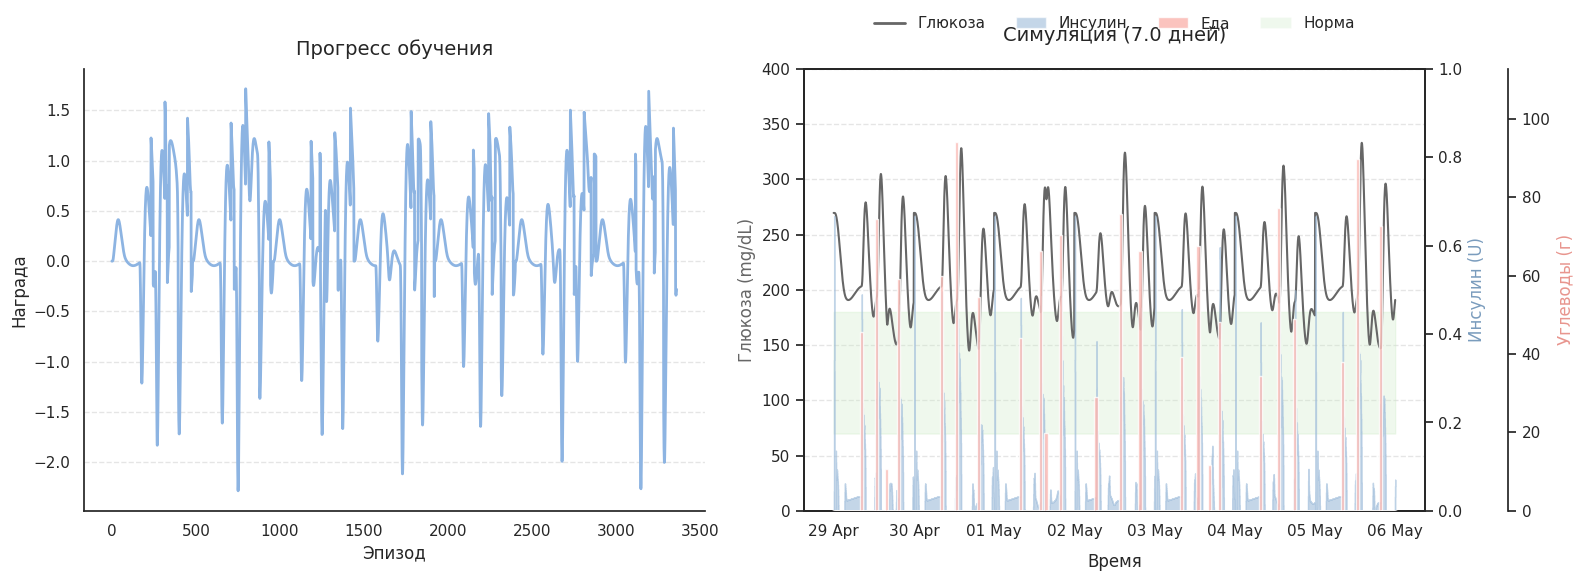

In [38]:
run_final_test_7_days(model, make_single_env("adult#005"))